# **NLP 1 - Intro to text mining & Natural Language Processing**

## Challenge

- Importe NLTK et télécharge les fonctions dont tu auras besoin (au fur et à mesure si nécessaire).
- Récupère le texte d'un article de presse de ton choix sur internet (en anglais ce sera plus simple, mais tu peux prendre la langue de ton choix). Affecte-le à une variable via un copier/coller dans ton notebook. Par simplicité pour la suite de cette quête, nous te conseillons de prendre un texte qui fait entre 10 et 30 lignes environ. 
- Transforme ton texte en tokens de phrases
- Transforme ton texte en tokens de mots
- Compte la fréquence d'apparition de chaque mot et réalise un graphique (si possible un diagramme en barre) qui représente les 20 mots les plus présents dans ton texte. Y a-t-il beaucoup de mots qui te semblent être des stopwords ?
- Enlève les stop words et la ponctuation, et regarde à nouveau quels sont les mots les plus présents. Là encore, réalise le même graphique pour comparer.

## Critères de validation

✅ Le notebook est consultable pour toute personne disposant du lien fourni par l'élève.  
✅ NLTK est utilisé pour réaliser le preprocessing du texte.  
✅ Les 2 graphiques demandés sont présents.  

In [110]:
# ================================================
# 🛜 Import des librairies
# ================================================
import nltk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# ================================================
# 🛜 Téléchargement des fonctions
# ================================================
nltk.download('popular')
nltk.download('punkt_tab')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/oneup/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!

True

In [127]:
# ================================================
# 🛜 Récupération d'un texte
# ================================================
# Ici on prend l'Abstract du texte sur "Attention is all you need" 
# https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf
text = """The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to
be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 Englishto-German translation task, improving over the existing best results, including
ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.0 after
training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature."""

In [112]:
# ================================================
# 🔧 Transformation du texte en tokens de phrases
# ================================================
text_phrase = nltk.sent_tokenize(text.lower())

In [113]:
# ================================================
# 🔧 Transformation du texte en tokens de mots
# ================================================
text_mot = nltk.word_tokenize(text.lower())

In [114]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots
# ================================================
# On cherche la fréquence d'apparition
freq = nltk.FreqDist(text_mot)
# On crée un dataframe avec les 20 mots ou caractères les plus fréquents
df = pd.DataFrame(freq.most_common(20), columns=["mot", "occurence"])

In [115]:
df.head()

,mot,occurence
0,the,10
1,",",8
2,on,6
3,.,6
4,models,4


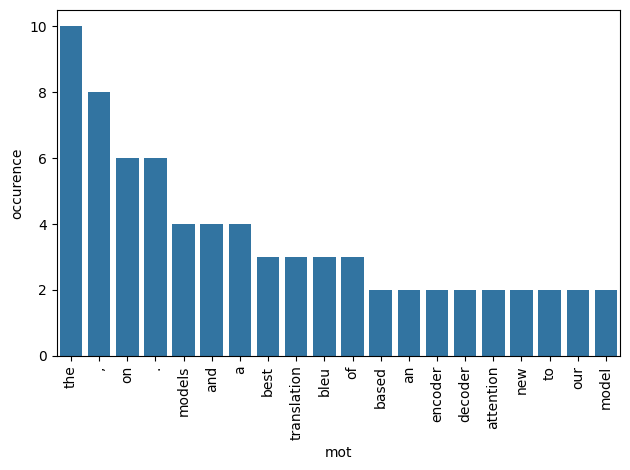

In [116]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents
# ================================================
sns.barplot(data=df, x='mot', y='occurence')
plt.xticks(rotation=90)
plt.tight_layout()

In [117]:
# ================================================
# 🥽 Vérification du taux d'apparition des Stop Words
# ================================================
stop_words = nltk.corpus.stopwords.words("english")
i = 0
for mot in df.mot:
    if mot in stop_words:
        i += 1
print(f"Sur les {len(df.mot)} mots il y en a {i} qui sont des 'stop words'")
print(f"Ce qui fait un taux de : {int((i*100)/len(df.mot))}%")

Sur les 20 mots il y en a 8 qui sont des 'stop words'
Ce qui fait un taux de : 40%


In [123]:
# ================================================
# 🧹 Nettoyage des Stop Words
# ================================================
text_mot_clean = []
for mots in text_mot:
  if mots not in stop_words:
    text_mot_clean.append(mots)

text_mot_clean

['dominant',
 'sequence',
 'transduction',
 'models',
 'based',
 'complex',
 'recurrent',
 'convolutional',
 'neural',
 'networks',
 'include',
 'encoder',
 'decoder',
 '.',
 'best',
 'performing',
 'models',
 'also',
 'connect',
 'encoder',
 'decoder',
 'attention',
 'mechanism',
 '.',
 'propose',
 'new',
 'simple',
 'network',
 'architecture',
 ',',
 'transformer',
 ',',
 'based',
 'solely',
 'attention',
 'mechanisms',
 ',',
 'dispensing',
 'recurrence',
 'convolutions',
 'entirely',
 '.',
 'experiments',
 'two',
 'machine',
 'translation',
 'tasks',
 'show',
 'models',
 'superior',
 'quality',
 'parallelizable',
 'requiring',
 'significantly',
 'less',
 'time',
 'train',
 '.',
 'model',
 'achieves',
 '28.4',
 'bleu',
 'wmt',
 '2014',
 'englishto-german',
 'translation',
 'task',
 ',',
 'improving',
 'existing',
 'best',
 'results',
 ',',
 'including',
 'ensembles',
 ',',
 '2',
 'bleu',
 '.',
 'wmt',
 '2014',
 'english-to-french',
 'translation',
 'task',
 ',',
 'model',
 'establish

In [124]:
# ================================================
# 🔢 Décompte de la fréquence d'apparition des 20 premier mots sans Stop Words
# ================================================
freq_clean = nltk.FreqDist(text_mot_clean)
df_clean = pd.DataFrame(freq_clean.most_common(20), columns=["mot", "occurence"])

In [120]:
df_clean.head()

,mot,occurence
0,",",8
1,.,6
2,models,4
3,best,3
4,translation,3


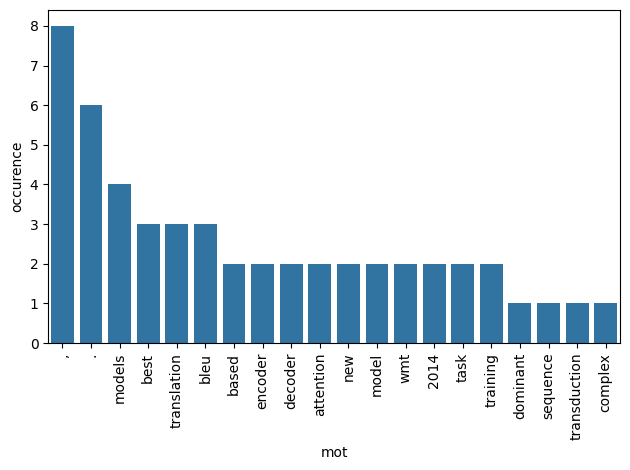

In [125]:
# ================================================
# 📊 Réalisation d'un graphique des 20 premier mots les plus fréquents sans Stop Words
# ================================================
sns.barplot(data=df_clean, x='mot', y='occurence')
plt.xticks(rotation=90)
plt.tight_layout()

In [126]:
# ================================================
# 🥽 Vérification du taux d'apparition des Stop Words
# ================================================
i = 0
for mot in df_clean.mot:
    if mot in stop_words:
        i += 1
print(f"Sur les {len(df.mot)} mots il y en a {i} qui sont des 'stop words'")
print(f"Ce qui fait un taux de : {int((i*100)/len(df.mot))}%")

Sur les 20 mots il y en a 0 qui sont des 'stop words'
Ce qui fait un taux de : 0%


## **Conclusion**

Le preprocessing a bien été effectuté. Les deux première tâches sont réalisés avec succès (tokenisation, suppression des Stop Words)
Les graphiques montre bien la différence.

On observe que la ponctuation est dominante avec les points et les virgules en tête de classement.
On aurait pu utiliser la méthode `nltk.WordPunctTokenizer()` afin de procéder au nettoyage de la ponctuation mais cela n'a pas été demandé dans l'exercice.
La suite serait donc de procéder à du stemming et/ou du lemmatizing.